<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 2 - Behavioral Research</h1>
            <h2>The primacy of behavioral research for understanding cognition... and the brain?</h2>
            <h4>École Normale Supérieure</h4>
            <p> Valentin Wyart <br>
                Amric Trudel <br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="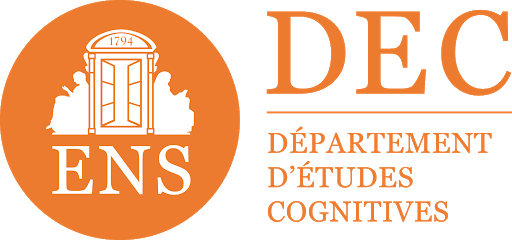
" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pybads import BADS
import scipy

EPSILON = 1e-6

## Random-dot motion


### Model

In [2]:
class MotionCoherenceModel:
    def __init__(self, A, k, t_R):
        self.A = A
        self.k = k
        self.t_R = t_R

    def predict_mean_reaction_time(self, x: float | np.ndarray) -> float | np.ndarray:
        t_T = self.A / (self.k * x) * np.tanh(self.A * self.k * x) + self.t_R
        return t_T

    def predict_mean_accuracy(self, x: float | np.ndarray) -> float | np.ndarray:
        p_c = 1 / (1 + np.exp(-2 * self.A * self.k * np.abs(x)))
        return p_c

    def log_likelihood(self, x, c) -> float:
        p_c = self.predict_mean_accuracy(x)
        ## Todo: Comprendre ou on met
        return np.sum(c * np.log(np.maximum(p_c, EPSILON)) +
                      (1 - c) * np.log(np.maximum((1 - p_c), EPSILON)))

    def rmse(self, x, t):
        t_T = self.predict_mean_reaction_time(x)
        return np.sqrt(np.mean((t - t_T) ** 2))

    @classmethod
    def fit(cls, x, t, c):
        def cost_function(params):
            model = cls(*params)
            log_likelihood = model.log_likelihood(x, c)
            rmse = model.rmse(x, t)
            return -log_likelihood + rmse

        optimizer = BADS(    # Params are A, k, t_R
            fun=cost_function,
            x0=np.array([20, 0.01, 100]),
            lower_bounds=np.array([0, 0.0001, 0]),
            upper_bounds=np.array([100, 1, 1000]),
            plausible_lower_bounds=np.array([5, 0.01, 10]),
            plausible_upper_bounds=np.array([50, 0.1, 500]),
            options={
                'display': 'iter'
            }
        )
        result = optimizer.optimize()
        optimal_params = {
            'A': result.x[0],
            'k': result.x[1],
            't_R': result.x[2]
        }
        return cls(**optimal_params)

    def __repr__(self)-> str:
        return f'MotionCoherenceModel(A={self.A:.2f}, k={self.k:.2f}, t_R={self.t_R:.2f})'

### Initial parameters

In [3]:
# Params
A = 20
k = 0.01
t_R =100

model = MotionCoherenceModel(A, k, t_R)

### Data Simulation

In [4]:
#Data
n_clusters = 8
n_trials_per_cluster = 100

coherence_clusters = np.logspace(-1, 2, num=n_clusters, base=10)

def generate_trials(coherence, n_trials):
    mean = model.predict_mean_reaction_time(coherence)
    std = mean / 4
    reaction_time = np.random.normal(mean, std, n_trials)
    prob_correct = model.predict_mean_accuracy(coherence)
    outcomes = np.random.binomial(1, prob_correct, size=n_trials)
    return reaction_time, outcomes

rts = []
outcms = []
for i, coherence in enumerate(coherence_clusters):
    reaction_time, outcome = generate_trials(coherence, n_trials_per_cluster)
    rts.append(reaction_time)
    outcms.append(outcome)

coherences = np.concat([np.full(n_trials_per_cluster, coherence) for coherence in coherence_clusters])
reaction_times = np.concat(rts)
outcomes = np.concat([np.full(n_trials_per_cluster, out) for out in outcms])

proportion_correct = np.array([outcome.mean() for outcome in outcms])

coherences.shape, reaction_times.shape, outcomes.shape, coherence_clusters.shape, proportion_correct.shape

((800,), (800,), (800,), (8,), (8,))

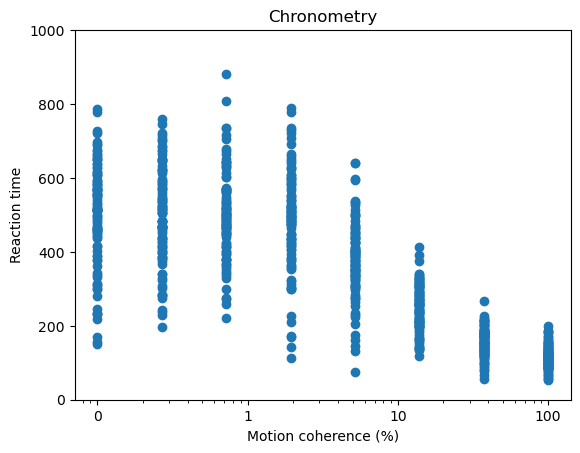

In [5]:
from matplotlib.ticker import ScalarFormatter, LogLocator

plt.scatter(coherences, reaction_times)
plt.title("Chronometry")
plt.ylabel("Reaction time")
plt.xlabel("Motion coherence (%)")
plt.xscale('log')
plt.ylim(0, 1000)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.show()

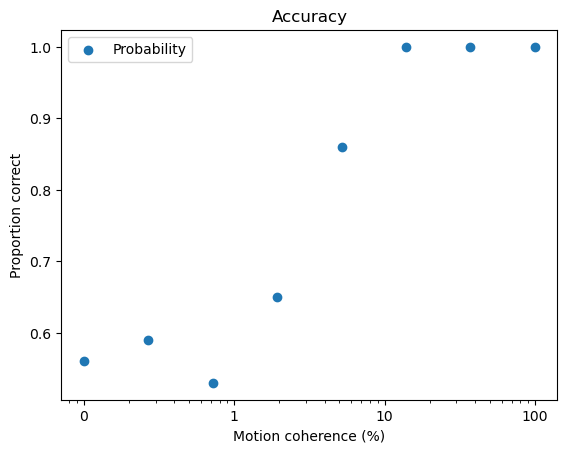

In [6]:
plt.scatter(coherence_clusters, proportion_correct, label='Probability')
# plt.scatter(, np.minimum(c + 0.5, 1), c='red', s=3, label='Outcome')
plt.title("Accuracy")
plt.ylabel("Proportion correct")
plt.xlabel("Motion coherence (%)")
plt.xscale('log')
# plt.xlim(0.05, 100)
# plt.ylim(0.45, 1.05)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.show()

### Parameter recovery

In [7]:
recovered_model = MotionCoherenceModel.fit(coherences, reaction_times, outcomes)

Variables (index) internally transformed to log coordinates: [[0 1]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         416.431               1                                 Uncertainty test
     0           6         416.431               1         Initial mesh            Initial points
     0          10         416.431             0.5         Refine grid             Train


/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/variable_transformer/variables_transformer.py:197: RuntimeWarning: overflow encountered in exp
  np.minimum(np.finfo(np.float64).max, np.exp(gamma * y + mu)),
/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)


     1          19         416.431            0.25         Refine grid             Train
     2          29         416.431           0.125         Refine grid             Train
     3          30           416.4           0.125     Incremental search (ES-wcm)        
     3          31         416.311           0.125     Successful search (ES-ell)        
     3          32         416.308           0.125     Incremental search (ES-ell)        
     3          34         416.295           0.125     Incremental search (ES-ell)        
     3          43         416.295          0.0625         Refine grid             Train
     4          53         416.295         0.03125         Refine grid             Train
     5          63         416.295        0.015625         Refine grid             Train
     6          64         416.292        0.015625     Successful search (ES-ell)        
     6          77         416.292       0.0078125         Refine grid             
     7          87

In [8]:
recovered_model

MotionCoherenceModel(A=20.01, k=0.01, t_R=96.66)

In [9]:
# Original Params
A, k, t_R

(20, 0.01, 100)

In [10]:
coherence_range = np.logspace(-1, 2, num=1000, base=10)

model_rt = recovered_model.predict_mean_reaction_time(coherence_range)

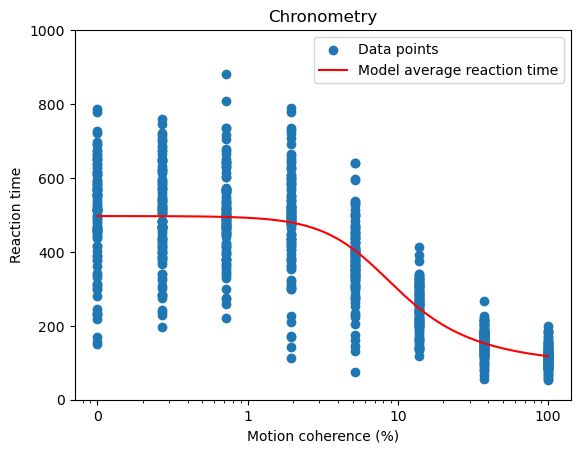

In [11]:
plt.scatter(coherences, reaction_times, label='Data points')
plt.plot(coherence_range, model_rt, color='red', label='Model average reaction time')
plt.title("Chronometry")
plt.ylabel("Reaction time")
plt.xlabel("Motion coherence (%)")
plt.xscale('log')
plt.ylim(0, 1000)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.show()

In [12]:
model_prob = recovered_model.predict_mean_accuracy(coherence_range)

In [13]:
coherence_clusters.shape, proportion_correct.shape

((8,), (8,))

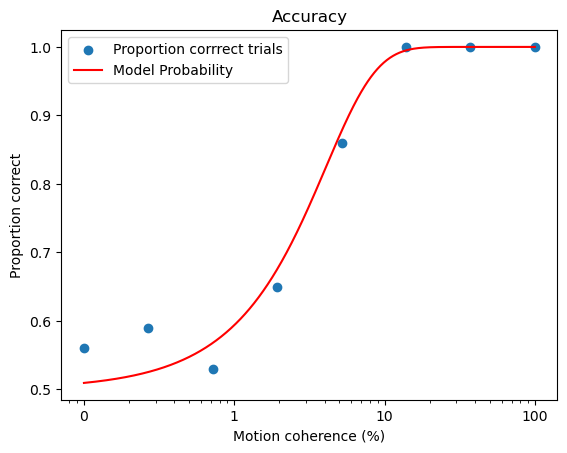

In [14]:
plt.scatter(coherence_clusters, proportion_correct, label='Proportion corrrect trials')
plt.plot(coherence_range, model_prob, label='Model Probability', color='red')
plt.title("Accuracy")
plt.ylabel("Proportion correct")
plt.xlabel("Motion coherence (%)")
plt.xscale('log')
# plt.xlim(0.05, 100)
# plt.ylim(0.45, 1.05)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.show()